# 내 프로젝트 v1

In [1]:
import pandas as pd

df = pd.read_csv('../../data/lam_etch_modify.csv')

print('전체 행 수:', df.shape[0])
print('전체 열 개수:', df.shape[1])
print('숫자형 열 개수:', df.select_dtypes(include='number').shape[1])
print()
print('result 값별 건수')
print(df['result'].value_counts())
print()
print('result 값별 비율')
print((df['result'].value_counts(normalize=True)*100).round(2))

전체 행 수: 12829
전체 열 개수: 23
숫자형 열 개수: 21

result 값별 건수
result
Pass    10770
Fail     2059
Name: count, dtype: int64

result 값별 비율
result
Pass    83.95
Fail    16.05
Name: proportion, dtype: float64


# 실습 16 - 문제 정의서

## Step 1. 문제 정의

**한 문장** : 반도체 공정의 센서 측정값으로, 검사 전에 불량 가능성이 높은 제품을 먼저 골라낸다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | Etch 공정 엔지니어 |
| 무엇을 결정하나 | 공정 중 발생한 이상 신호를 보고 공정을 멈출지 말지 / etch 공정이 완료된 웨이퍼를 후속 공정으로 보낼지 말지 |
| 언제 결정하나 | 식각 공정이 끝난 직후, 다음 공정으로 넘어가기 전 |
| 이 판단이 늦으면 | 불량 웨이퍼가 다음 공정으로 넘어갈수록 비용과 시간이 낭비됨. 수율 하락  |

## Step 2. 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | [공개 데이터 중 machine data] |
| 규모 | [12,829행 x 23열] |
| 입력으로 쓸 열 | [숫자로 된 측정 열 21개] |
| 결과 열 | [result] |
| 결과 열의 값 | [Pass/Fail] |
| 기준선이 될 숫자 | [불합격 2059건 (16.05%)] |

## Step 3. 한계

- **상관관계 ≠ 인과관계**: 특정 측정값이 높은 구간에서 불합격이 많이 관찰되더라도, 그것이 원인이라고 말하면 안된다. 그럴 확률이 높을 뿐이다.
- **클래스 불균형이 accuracy를 착시로 만든다**: `result`는 Pass 83.95%, Fail 16.05%로 불균형하다. accuracy 0.85는 모든 웨이퍼를 Pass로만 찍어도 나오는 수준이라, 이 숫자만으로 모델이 쓸모 있다고 판단하면 안 된다.
- **이 데이터는 `Step Number` 4, 5 구간만 담고 있다**: 식각 공정의 다른 스텝에서 벌어지는 이상은 이 데이터로는 볼 수 없어, "반사전력 이상 없음 = 전체 공정이 안전"이라고 일반화할 수 없다.

# 추가 분석 - 데이터 전처리

## 16-1) 데이터 확인

In [2]:
import pandas as pd

df = pd.read_csv('../../data/lam_etch_modify.csv')

print('1. 전체 행 수와 열 수')
print('행:', df.shape[0], '/ 열:', df.shape[1])
print()

print('2. result 값별 건수와 비율')
print(df['result'].value_counts())
print()
print((df['result'].value_counts(normalize=True) * 100).round(2))
print()

print('3. head() 화면 표시 확인')
print('pandas display.max_columns 설정값:', pd.get_option('display.max_columns'))
print('데이터 열 수:', df.shape[1])
max_cols = pd.get_option('display.max_columns')
if max_cols is not None and df.shape[1] > max_cols:
    print('-> 열 수(%d)가 display.max_columns(%d)보다 많아 head()에서 가운데 열이 "..."로 생략된다' % (df.shape[1], max_cols))
else:
    print('-> 열이 전부 화면에 표시된다')
print()
df.head()

1. 전체 행 수와 열 수
행: 12829 / 열: 23

2. result 값별 건수와 비율
result
Pass    10770
Fail     2059
Name: count, dtype: int64

result
Pass    83.95
Fail    16.05
Name: proportion, dtype: float64

3. head() 화면 표시 확인
pandas display.max_columns 설정값: 20
데이터 열 수: 23
-> 열 수(23)가 display.max_columns(20)보다 많아 head()에서 가운데 열이 "..."로 생략된다



,wafer_id,Time,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,...,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve,result
0,l2901.txm,11.9460,4.0,751.0,753.0,132.0,0.0,626.0,100.0,1227.0,...,26.0,16599.0,20028.0,-296.0,16848.0,360.0,0.0,27594.0,49.0,Pass
1,l2901.txm,13.0280,4.0,751.0,753.0,134.0,0.0,620.0,99.0,1229.0,...,26.0,16568.0,20042.0,-676.0,16796.0,350.0,0.0,27440.0,49.0,Pass
2,l2901.txm,14.0490,4.0,751.0,755.0,134.0,0.0,599.0,102.0,1221.0,...,25.0,16442.0,20146.0,-291.0,16512.0,344.0,0.0,27276.0,49.0,Pass
3,l2901.txm,15.1329,4.0,751.0,753.0,133.0,0.0,586.0,100.0,1201.0,...,25.0,16960.0,20148.0,-262.0,17020.0,352.0,0.0,27330.0,50.0,Pass
4,l2901.txm,16.1390,4.0,751.0,754.0,132.0,0.0,587.0,102.0,1182.0,...,25.0,16564.0,20226.0,-547.0,16440.0,346.0,0.0,27262.0,50.0,Pass


## 16-2) 전처리 - 결측치/상수열 확인

In [3]:
import pandas as pd
from IPython.display import display, HTML

df = pd.read_csv('../../data/lam_etch_modify.csv')

exclude_cols = ['wafer_id', 'result', 'Time']
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude_cols]

summary = pd.DataFrame({
    '센서이름': numeric_cols,
    '최소값': [df[c].min() for c in numeric_cols],
    '최대값': [df[c].max() for c in numeric_cols],
    '고유값 개수': [df[c].nunique() for c in numeric_cols],
})
summary['값의 범위(최소~최대)'] = summary['최소값'].astype(str) + ' ~ ' + summary['최대값'].astype(str)
summary = summary[['센서이름', '값의 범위(최소~최대)', '고유값 개수']]

print('문자열 열(wafer_id, result), Time 열을 뺀 숫자형 열 개수:', len(numeric_cols))
print()
print('상위 5개')
display(summary.head(5))

html = summary.to_html(index=False)
display(HTML(f'<details><summary>전체 {len(summary)}개 펼쳐보기</summary>{html}</details>'))

print()
print('참고(확실하지 않음): 고유값 개수가 아주 적은 열(예: RF Btm Rfl Pwr, TCP Rfl Pwr)은')
print('연속형 센서값이라기보다 사실상 범주형/이진값에 가까워 보이는데,')
print('이게 장비 스펙상 원래 그런 값인지 계측 해상도 한계인지는 이 데이터만으로는 확실하지 않다.')

문자열 열(wafer_id, result), Time 열을 뺀 숫자형 열 개수: 20

상위 5개


,센서이름,값의 범위(최소~최대),고유값 개수
0,Step Number,4.0 ~ 5.0,2
1,BCl3 Flow,724.4693877551019 ~ 776.4693877551019,15
2,Cl2 Flow,748.0 ~ 757.0,23
3,RF Btm Pwr,124.0 ~ 142.0,52
4,RF Btm Rfl Pwr,0.0 ~ 1.0,2


센서이름,값의 범위(최소~최대),고유값 개수
Step Number,4.0 ~ 5.0,2
BCl3 Flow,724.4693877551019 ~ 776.4693877551019,15
Cl2 Flow,748.0 ~ 757.0,23
RF Btm Pwr,124.0 ~ 142.0,52
RF Btm Rfl Pwr,0.0 ~ 1.0,2
Endpt A,272.0 ~ 3464.0,1855
He Press,98.12061224489796 ~ 103.12061224489796,10
Pressure,942.05179028133 ~ 1410.3295238095238,293
RF Tuner,9311.0 ~ 9805.0,312
RF Load,8811.0 ~ 9321.0,392



참고(확실하지 않음): 고유값 개수가 아주 적은 열(예: RF Btm Rfl Pwr, TCP Rfl Pwr)은
연속형 센서값이라기보다 사실상 범주형/이진값에 가까워 보이는데,
이게 장비 스펙상 원래 그런 값인지 계측 해상도 한계인지는 이 데이터만으로는 확실하지 않다.


## 16-3) 노이즈 제거 + step별로 csv 파일 분리

In [4]:
df = pd.read_csv('../../data/lam_etch_modify.csv')

neg_rows = df[df['TCP Rfl Pwr'] == -1]
print('TCP Rfl Pwr == -1 인 행 수:', len(neg_rows))
neg_rows

TCP Rfl Pwr == -1 인 행 수: 1


,wafer_id,Time,Step Number,BCl3 Flow,Cl2 Flow,RF Btm Pwr,RF Btm Rfl Pwr,Endpt A,He Press,Pressure,...,RF Pwr,RF Impedance,TCP Tuner,TCP Phase Err,TCP Impedance,TCP Top Pwr,TCP Rfl Pwr,TCP Load,Vat Valve,result
8858,l3321.txm,38.7656,4.0,751.0,753.0,132.0,0.0,898.0,100.0,1227.0,...,28.0,16871.0,19108.0,74.0,16650.0,346.0,-1.0,28292.0,49.0,Pass


In [5]:
import os

df = pd.read_csv('../../data/lam_etch_modify.csv')

mask = df['TCP Rfl Pwr'] == -1
print('수정 대상 행 수:', mask.sum())

df.loc[mask, 'TCP Rfl Pwr'] = 0

os.makedirs('result', exist_ok=True)
save_path = 'result/lam_etch_modify_2.csv'
df.to_csv(save_path, index=False)
print('저장 경로:', os.path.abspath(save_path))

check = pd.read_csv(save_path)
print()
print('저장된 파일에서 해당 행 확인')
print(check.loc[mask, ['wafer_id', 'Time', 'TCP Rfl Pwr']])

original = pd.read_csv('../../data/lam_etch_modify.csv')
print()
print('원본 파일은 그대로인지 확인')
print(original.loc[mask, ['wafer_id', 'Time', 'TCP Rfl Pwr']])

수정 대상 행 수: 1


저장 경로: C:\Users\subin\OneDrive\바탕 화면\secome-project\day06\project_lam\result\lam_etch_modify_2.csv



저장된 파일에서 해당 행 확인
       wafer_id     Time  TCP Rfl Pwr
8858  l3321.txm  38.7656          0.0



원본 파일은 그대로인지 확인
       wafer_id     Time  TCP Rfl Pwr
8858  l3321.txm  38.7656         -1.0


In [6]:
df2 = pd.read_csv('result/lam_etch_modify_2.csv')

print('lam_etch_modify_2.csv 행/열:', df2.shape)
print(df2['Step Number'].value_counts().sort_index())

step4 = df2[df2['Step Number'] == 4].drop(columns='Step Number')
step5 = df2[df2['Step Number'] == 5].drop(columns='Step Number')

step4.to_csv('result/lam_etch_step4.csv', index=False)
step5.to_csv('result/lam_etch_step5.csv', index=False)

print()
print('lam_etch_step4.csv 행/열:', step4.shape, '(Step Number 열 제거, wafer_id는 유지)')
print('lam_etch_step5.csv 행/열:', step5.shape, '(Step Number 열 제거, wafer_id는 유지)')
print('합계 == 원본 행 수?', len(step4) + len(step5) == len(df2))
print('Step Number 열이 빠졌는지 확인:', 'Step Number' not in step4.columns and 'Step Number' not in step5.columns)
print('wafer_id 열이 남아있는지 확인:', 'wafer_id' in step4.columns and 'wafer_id' in step5.columns)

print()
print('원본(lam_etch_modify_2.csv)은 그대로인지 확인')
check_original = pd.read_csv('result/lam_etch_modify_2.csv')
print('행/열:', check_original.shape, '(Step Number 포함 여부:', 'Step Number' in check_original.columns, ')')

lam_etch_modify_2.csv 행/열: (12829, 23)
Step Number
4.0    6025
5.0    6804
Name: count, dtype: int64



lam_etch_step4.csv 행/열: (6025, 22) (Step Number 열 제거, wafer_id는 유지)
lam_etch_step5.csv 행/열: (6804, 22) (Step Number 열 제거, wafer_id는 유지)
합계 == 원본 행 수? True
Step Number 열이 빠졌는지 확인: True
wafer_id 열이 남아있는지 확인: True

원본(lam_etch_modify_2.csv)은 그대로인지 확인


행/열: (12829, 23) (Step Number 포함 여부: True )


## 16-4) 각 열의 기초 통계량 확인

In [7]:
import numpy as np
from IPython.display import display

def make_sensor_diagnosis(df, label):
    rows = []
    for col in df.columns:
        s = df[col]
        missing_pct = s.isna().mean() * 100
        nunique = s.nunique()
        if pd.api.types.is_numeric_dtype(s):
            std = s.std()
            vmin = s.min()
            vmax = s.max()
        else:
            std = np.nan
            vmin = s.min()
            vmax = s.max()
        rows.append({
            '열 이름': col,
            '빈칸 비율(%)': round(missing_pct, 4),
            '고유값 개수': nunique,
            '표준편차': std,
            '최솟값': vmin,
            '최댓값': vmax,
        })
    result = pd.DataFrame(rows).sort_values('빈칸 비율(%)', ascending=False).reset_index(drop=True)
    print(f'[{label}] sensor_diagnosis 전체 줄 수: {len(result)}')
    display(result.head(10))
    return result

step4 = pd.read_csv('result/lam_etch_step4.csv')
step5 = pd.read_csv('result/lam_etch_step5.csv')

print('=== lam_etch_step4.csv ===')
sensor_diagnosis_step4 = make_sensor_diagnosis(step4, 'lam_etch_step4')

print()
print('=== lam_etch_step5.csv ===')
sensor_diagnosis_step5 = make_sensor_diagnosis(step5, 'lam_etch_step5')

=== lam_etch_step4.csv ===


[lam_etch_step4] sensor_diagnosis 전체 줄 수: 22


,열 이름,빈칸 비율(%),고유값 개수,표준편차,최솟값,최댓값
0,wafer_id,0.0,129,NaN,l2901.txm,l3343.txm
1,Time,0.0,3586,14.054670,8.66797,65.559
2,BCl3 Flow,0.0,11,2.394470,724.469388,753.0
3,Cl2 Flow,0.0,23,0.784381,748.0,757.0
4,RF Btm Pwr,0.0,46,1.818129,124.0,142.0
5,RF Btm Rfl Pwr,0.0,2,0.107923,0.0,1.0
6,Endpt A,0.0,1420,845.151163,296.0,3464.0
7,He Press,0.0,10,0.752731,98.120612,103.120612
8,Pressure,0.0,249,30.834546,942.05179,1410.329524
9,RF Tuner,0.0,250,40.903540,9311.0,9805.0



=== lam_etch_step5.csv ===


[lam_etch_step5] sensor_diagnosis 전체 줄 수: 22


,열 이름,빈칸 비율(%),고유값 개수,표준편차,최솟값,최댓값
0,wafer_id,0.0,128,NaN,l2901.txm,l3343.txm
1,Time,0.0,4828,15.980762,54.5879,127.259
2,BCl3 Flow,0.0,12,2.095481,750.0,776.469388
3,Cl2 Flow,0.0,20,0.712598,750.0,757.0
4,RF Btm Pwr,0.0,31,1.353895,130.0,137.0
5,RF Btm Rfl Pwr,0.0,2,0.112996,0.0,1.0
6,Endpt A,0.0,1094,461.372696,272.0,2007.0
7,He Press,0.0,10,0.728308,98.120612,103.120612
8,Pressure,0.0,193,23.171996,973.05179,1393.329524
9,RF Tuner,0.0,278,47.787279,9314.0,9781.0


---
# 실습 17 - 모델링 계획표

## Step 4. 모델링 계획

| # | 하는 일 | 내 경우엔 | 막힐 것 같나 |
|---|---|---|---|
| 1 | 파일 불러오기 | result/lam_etch_step4.csv<br>result/lam_etch_step5.csv<br>*섞어서 학습시키면 "스텝이 달라서 나는 차이"와 "불량이라서 나는 차이"가 뒤섞일 수 있음<br>*step5는 같은 계획표를 복사해서 따로 돌릴 예정 | |
| 2 | 빈칸 채우기 | 결측치가 없어 수행하지 않음 |  |
| 3 | 결과 열을 숫자로 | result가 "Fail"이면 1, 아니면 0 | |
| 4 | 입력과 정답 나누기 | 입력은 센서 열 19개, 정답은 result<br>*원본 23열 - 4개 열(time/wafer_id/step_number/result) | |
| 5 | 학습용·시험용 나누기 | wafer_id 단위로 먼저 8:2로 나눈 뒤, 그 웨이퍼에 속한 행을 통째로 학습/시험에 배정 (불량 웨이퍼 비율도 양쪽에 맞춰서) | |
| 6 | 기준 모델 점수 재기 | 전부 양품이라 답하는 모델 | |
| 7 | 모델 하나 학습시키기 | 표준화한 뒤 로지스틱 회귀 | 막힐 것 같음 |
| 8 | 결과 읽기 | 기준 모델과 나란히 놓고 비교 | 막힐 것 같음 |

## 추천 모델 순위

| 순위 | 모델명 | 추천 이유 1줄 | 주의할 점 |
|---|---|---|---|
| 1 | 로지스틱 회귀 (표준화 후) | 계수로 어떤 센서가 Fail 쪽으로 미는지 엔지니어에게 바로 설명할 수 있다 | 선형 경계라 `RF Btm Rfl Pwr`처럼 사실상 이진값인 열이 섞인 데이터에서는 한계가 있을 수 있다 |
| 2 | 랜덤포레스트 | 스케일링 없이도 되고 `feature_importances_`로 19개 센서 중 중요한 것의 순위를 바로 뽑을 수 있다 | 웨이퍼 수가 적어(129개) 트리가 깊어지면 과적합하기 쉽다 |
| 3 | 그래디언트 부스팅 | 표 형태 데이터에서 성능 상한이 가장 높은 편이다 | 튜닝 부담이 크고 표본이 작아(Fail 21개) 과적합 위험이 1·2순위보다 크다 — 1·2순위 기준을 넘는지 확인용으로만 마지막에 시도 |

공통 주의사항: `lam_etch_step4.csv`/`lam_etch_step5.csv`는 행 단위(웨이퍼 1개당 여러 행)라, `wafer_id` 기준으로 먼저 학습·시험을 나눈 뒤 그 웨이퍼에 속한 행을 통째로 넣어야 같은 웨이퍼가 학습·시험 양쪽에 섞이는 걸 막을 수 있다.

---
# 실습 18 - 모델링 v1

## Step 5. 모델링 v1

### 문법 노트 - 코드에서 찾을 이름

| 이름 | 뜻 |
|---|---|
| features | 모델에 넣는 입력 열 목록 |
| label | 정답표 - 찾으려는 쪽이면 1, 아니면 0 |
| X / y | 입력 / 정답 |
| X_train, X_test | 학습용 입력 / 시험용 입력 |
| y_train, y_test | 학습용 정답 / 시험용 정답 |
| baseline | 기준 모델 - 학습 없이 전부 아니라고 답하는 것 |
| model | 학습시킨 모델 |
| y_pred | 모델이 내놓은 답 |
| precision / recall | 정밀도 / 재현율 |

### 이번 v1에서 볼 숫자

- 볼 지표 : 기준 모델 정확도 / 정확도 accuracy / 정밀도 precision / 재현율 recall
- 이걸 보는 이유 : 불량이 16.05%라 전부 양품이라 답해도 83.95%가 넘는다. 정확도만 보면 잘한 걸로 착각한다

### 내 갈래

- 갈래 : A - 결과 맞히기
- 결과 열 : result / 관심 갈래 : Fail
- 이 기준으로 정한 이유 : 수율 손실을 만드는 원인을 조기에 잡아내기 위함

---
## Step 6. wafer_id 기준으로 나눠서 모델 학습

In [8]:
# 1. 파일을 불러온다
df = pd.read_csv('result/lam_etch_step4.csv')

# 2. 숫자로 된 열만 입력 후보로 삼는다
numeric_cols = df.select_dtypes(include='number').columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'Time']  # Time은 입력에서 제외
feature_cols = [c for c in feature_cols if c != 'wafer_id']  # wafer_id는 문자열이라 이미 빠져있지만 명시적으로 한 번 더 제외 (5번에서 그룹 나눌 때 df에는 그대로 남겨둠)

# 3. result는 답이므로 입력에서 뺀다 (result는 문자열이라 numeric_cols에 애초에 없음, 확인 차 한 번 더 제외)
feature_cols = [c for c in feature_cols if c != 'result']

# 4. result가 "Fail"이면 1, 아니면 0인 label 열을 만든다
df['label'] = (df['result'] == 'Fail').astype(int)

print('입력으로 쓸 열 개수:', len(feature_cols))
print(feature_cols)

입력으로 쓸 열 개수: 19
['BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A', 'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err', 'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err', 'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve']


### 16-1) 학습용/시험용 데이터 나누기(층화추출)

In [9]:
# 5. 학습용과 시험용을 wafer_id 단위로 8:2로 나눈다
from sklearn.model_selection import train_test_split

# 웨이퍼 목록(중복 없이)과 그 웨이퍼의 label을 만든다
wafer_label = df.groupby('wafer_id')['label'].first()

# 웨이퍼를 8:2로 나눈다 (양쪽 불량 웨이퍼 비율이 같도록 stratify)
train_wafers, test_wafers = train_test_split(
    wafer_label.index,
    test_size=0.2,
    random_state=42,
    stratify=wafer_label.values,
)

# 나뉜 웨이퍼에 속한 행 전체를 학습용/시험용으로 통째로 배정한다
train_df = df[df['wafer_id'].isin(train_wafers)]
test_df = df[df['wafer_id'].isin(test_wafers)]

# 같은 웨이퍼가 학습용과 시험용에 동시에 들어가지 않았는지 확인
overlap = set(train_df['wafer_id']) & set(test_df['wafer_id'])

print('학습용 웨이퍼 수:', len(train_wafers), '/ 시험용 웨이퍼 수:', len(test_wafers))
print('학습용 웨이퍼 중 불량 비율:', round(wafer_label.loc[train_wafers].mean(), 4))
print('시험용 웨이퍼 중 불량 비율:', round(wafer_label.loc[test_wafers].mean(), 4))
print('학습용 행 수:', len(train_df), '/ 시험용 행 수:', len(test_df))
print('학습용/시험용에 겹치는 웨이퍼 수(0이어야 정상):', len(overlap))

# 입력(X)과 정답(y)을 나눈다
X_train = train_df[feature_cols]
y_train = train_df['label']
X_test = test_df[feature_cols]
y_test = test_df['label']

학습용 웨이퍼 수: 103 / 시험용 웨이퍼 수: 26
학습용 웨이퍼 중 불량 비율: 0.165
시험용 웨이퍼 중 불량 비율: 0.1538
학습용 행 수: 4791 / 시험용 행 수: 1234
학습용/시험용에 겹치는 웨이퍼 수(0이어야 정상): 0


### 16-2) 기준모델, 로지스틱 회귀-일반 학습 및 시험

In [10]:
# 6. 기준 모델 점수를 먼저 잰다 - 시험용 전부 0(양품)이라 답했을 때의 정확도
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_pred = pd.Series(0, index=y_test.index)
baseline_acc = accuracy_score(y_test, baseline_pred)

# 7. 표준화를 한 뒤 로지스틱 회귀 모델을 학습시킨다
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 표준화 기준은 학습용에서만 구한다(fit)
X_test_scaled = scaler.transform(X_test)  # 시험용에는 구해둔 기준을 적용만 한다(transform)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)  # 학습은 학습용으로만
y_pred = model.predict(X_test_scaled)  # 예측은 시험용으로만

# 8. 시험용 기준으로 일곱 줄을 출력한다
model_acc = accuracy_score(y_test, y_pred)
지목한_건수 = int((y_pred == 1).sum())
그중_진짜 = int(((y_pred == 1) & (y_test.values == 1)).sum())
시험용_실제_건수 = int((y_test == 1).sum())
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc, 4))
print('내 모델 정확도:', round(model_acc, 4))
print('지목한 건수:', 지목한_건수)
print('그중 진짜:', 그중_진짜)
print('시험용의 실제 건수:', 시험용_실제_건수)
print('정밀도:', round(precision, 4))
print('재현율:', round(recall, 4))
print('F1:', round(f1, 4))

기준 모델 정확도: 0.8444
내 모델 정확도: 0.8436
지목한 건수: 1
그중 진짜: 0
시험용의 실제 건수: 192
정밀도: 0.0
재현율: 0.0
F1: 0.0


### 16-3) 로지스틱회귀-클래스 가중치 학습 및 시험

In [11]:
# class_weight='balanced'로 클래스 불균형을 보정한 로지스틱 회귀
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)  # 학습은 학습용으로만 (앞 칸과 동일한 X_train_scaled/y_train 재사용)
y_pred_balanced = model_balanced.predict(X_test_scaled)  # 예측은 시험용으로만

# balanced가 실제로 Pass/Fail에 매긴 가중치 확인 (n_samples / (n_classes * 그 클래스 개수))
n_samples = len(y_train)
n_pass = int((y_train == 0).sum())
n_fail = int((y_train == 1).sum())
weight_pass = n_samples / (2 * n_pass)
weight_fail = n_samples / (2 * n_fail)

print('학습용 Pass 행 수:', n_pass, '/ Fail 행 수:', n_fail)
print('class_weight=balanced가 매긴 가중치 -> Pass:', round(weight_pass, 4), '/ Fail:', round(weight_fail, 4))
print()

# 기준 모델·balanced 모델 결과를 같은 7줄로 비교
model_acc_balanced = accuracy_score(y_test, y_pred_balanced)
지목한_건수_balanced = int((y_pred_balanced == 1).sum())
그중_진짜_balanced = int(((y_pred_balanced == 1) & (y_test.values == 1)).sum())
시험용_실제_건수 = int((y_test == 1).sum())
precision_balanced = precision_score(y_test, y_pred_balanced, zero_division=0)
recall_balanced = recall_score(y_test, y_pred_balanced, zero_division=0)
f1_balanced = f1_score(y_test, y_pred_balanced, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc, 4))
print('balanced 모델 정확도:', round(model_acc_balanced, 4))
print('지목한 건수:', 지목한_건수_balanced)
print('그중 진짜:', 그중_진짜_balanced)
print('시험용의 실제 건수:', 시험용_실제_건수)
print('정밀도:', round(precision_balanced, 4))
print('재현율:', round(recall_balanced, 4))
print('F1:', round(f1_balanced, 4))

학습용 Pass 행 수: 4035 / Fail 행 수: 756
class_weight=balanced가 매긴 가중치 -> Pass: 0.5937 / Fail: 3.1687

기준 모델 정확도: 0.8444
balanced 모델 정확도: 0.5259
지목한 건수: 427
그중 진짜: 17
시험용의 실제 건수: 192
정밀도: 0.0398
재현율: 0.0885
F1: 0.0549


### 16-4) 3개 모델 비교 

| 지표 | 기준모델 | 로지스틱 회귀 일반 | 로지스틱회귀-클래스가중치 |
|---|---|---|---|
| 정확도 | 0.8444 | 0.8436 | 0.5259 |
| 지목한 건수 | - | 1 | 427 |
| 그중 진짜 | - | 0 | 17 |
| 시험용의 실제 건수 | 192 | 192 | 192 |
| 정밀도 | - | 0.0 | 0.0398 |
| 재현율 | - | 0.0 | 0.0885 |
| F1 | - | 0.0 | 0.0549 |

로지스틱 회귀 일반은 정확도만 보면 기준모델과 거의 같아 보이지만 실제로는 Fail을 하나도 못 잡는다(재현율 0). class_weight='balanced'는 재현율을 0→8.85%로 끌어올렸지만, 그 대가로 정확도가 크게 떨어지고 정밀도도 3.98%에 불과해 알람이 너무 많이 울리는 상태다.

### 16-5) 로지스틱 회귀 일반 모델이 왜 Fail을 못 잡는지 확인 - 예측 확률 분포

In [12]:
# 앞서 학습한 '로지스틱 회귀 일반' 모델(model)이 시험용 각 행에 매긴 Fail(1)일 확률을 직접 뽑아본다
proba = model.predict_proba(X_test_scaled)[:, 1]

print('시험용 전체 1,234행의 Fail 예측 확률 분포')
print(pd.Series(proba).describe())
print()
print('예측 확률이 0.5 이상인 행 수 (=1로 판정된 행 수):', int((proba >= 0.5).sum()))
print('예측 확률 상위 5개:', sorted(proba, reverse=True)[:5])
print()

print('실제 Fail인 행(192개)만 따로 봤을 때, 모델이 매긴 확률 분포')
print(pd.Series(proba)[y_test.values == 1].describe())

시험용 전체 1,234행의 Fail 예측 확률 분포
count    1234.000000
mean        0.123802
std         0.081526
min         0.002921
25%         0.057313
50%         0.116903
75%         0.171515
max         0.509940
dtype: float64

예측 확률이 0.5 이상인 행 수 (=1로 판정된 행 수): 1
예측 확률 상위 5개: [np.float64(0.5099403309290438), np.float64(0.4809410682792429), np.float64(0.46364844527374816), np.float64(0.4320218539801018), np.float64(0.43001318376520203)]

실제 Fail인 행(192개)만 따로 봤을 때, 모델이 매긴 확률 분포
count    192.000000
mean       0.055373
std        0.063485
min        0.002921
25%        0.014676
50%        0.028154
75%        0.079860
max        0.414475
dtype: float64


---
## Step 7. 웨이퍼 단위로 압축해서 모델 다시 만들기

### 17-1) 압축이 필요한 이유 · 장단점 · 주의사항

**왜 압축해야 하는가**
- 16-5에서 확인했듯, 행(시점) 단위 원시 센서값은 label(웨이퍼 단위 Fail 여부)과 뚜렷한 관계가 없었다 — 오히려 실제 Fail 행의 예측 확률이 전체 평균보다 낮게 나왔다.
- `label`은 원래 웨이퍼 단위로 정의된 값인데 입력은 시점 단위로 넣고 있어서, 신호 대 잡음비가 낮아지는 구조적 문제가 있다.
- 한 웨이퍼의 여러 시점을 평균·표준편차 같은 통계값으로 압축하면, 입력의 단위가 label의 단위(웨이퍼)와 일치하게 되어 "이 웨이퍼가 전체적으로 어떤 경향을 보였는가"를 하나의 벡터로 나타낼 수 있다.

**장점**
- 표본 단위와 라벨 단위가 일치해서, 같은 웨이퍼 안에서 라벨이 뒤섞이는 문제가 근본적으로 사라진다
- 시점 단위 잡음이 평균으로 상쇄되어 신호 대 잡음비가 개선될 가능성이 있다
- 1행 = 1웨이퍼가 되므로 학습/시험 분할이 단순해진다 (wafer_id 그룹 분할이 더 이상 필요 없음)

**단점**
- 순간적인 이상(스파이크)이 평균에 묻혀 사라질 수 있다 — 표준편차를 같이 넣어 일부 보완하지만 완전히 막지는 못한다
- 웨이퍼 수(129개, Fail 21개) 자체는 그대로라 근본적인 표본 부족은 해결되지 않는다
- 압축은 정보 손실을 동반한다 — 되돌릴 수 없다

**자료 해석 시 주의사항**
- 웨이퍼당 시점 수가 최소 3개(예: l3125.txm)까지 있어, 그런 웨이퍼의 표준편차는 시점이 많은 웨이퍼(50개 안팎)의 표준편차보다 신뢰도가 낮다
- 압축된 값끼리 관계가 보여도 여전히 상관관계일 뿐 인과관계가 아니다
- step4/step5는 이번에도 각각 따로 압축해서 모델링한다 (섞으면 스텝 차이와 불량 차이가 뒤섞이는 문제는 그대로 유효)

### 17-2) 웨이퍼 단위로 압축해서 새 CSV로 저장

In [13]:
# lam_etch_step4.csv / lam_etch_step5.csv를 다시 불러온다 (원본은 그대로 두고 새 변수로만 사용)
step4_raw = pd.read_csv('result/lam_etch_step4.csv')
step5_raw = pd.read_csv('result/lam_etch_step5.csv')

# 압축 대상 센서 열 (wafer_id, Time, result 제외)
sensor_cols = [c for c in step4_raw.columns if c not in ['wafer_id', 'Time', 'result']]
print('압축할 센서 열 개수:', len(sensor_cols))

def aggregate_by_wafer(raw_df, sensor_cols):
    g = raw_df.groupby('wafer_id')
    agg = g[sensor_cols].agg(['mean', 'std'])  # 센서마다 평균/표준편차 2개씩
    agg.columns = [f'{col}_{stat}' for col, stat in agg.columns]  # 예: 'BCl3 Flow_mean'
    agg.insert(0, 'n_rows', g.size())  # 참고용 - 그 웨이퍼의 원래 시점 수 (모델 입력에는 안 씀)
    agg['result'] = g['result'].first()  # 웨이퍼 단위 정답
    return agg.reset_index()

step4_agg = aggregate_by_wafer(step4_raw, sensor_cols)
step5_agg = aggregate_by_wafer(step5_raw, sensor_cols)

step4_agg.to_csv('result/lam_etch_step4_agg.csv', index=False)
step5_agg.to_csv('result/lam_etch_step5_agg.csv', index=False)

print('lam_etch_step4_agg.csv 행/열:', step4_agg.shape)
print('lam_etch_step5_agg.csv 행/열:', step5_agg.shape)
print()
print('n_rows(웨이퍼당 시점 수) 분포 - step4')
print(step4_agg['n_rows'].describe())
step4_agg.head()

압축할 센서 열 개수: 19
lam_etch_step4_agg.csv 행/열: (129, 41)
lam_etch_step5_agg.csv 행/열: (128, 41)

n_rows(웨이퍼당 시점 수) 분포 - step4
count    129.000000
mean      46.705426
std        5.711013
min        3.000000
25%       46.000000
50%       47.000000
75%       48.000000
max       53.000000
Name: n_rows, dtype: float64


,wafer_id,n_rows,BCl3 Flow_mean,BCl3 Flow_std,Cl2 Flow_mean,Cl2 Flow_std,RF Btm Pwr_mean,RF Btm Pwr_std,RF Btm Rfl Pwr_mean,RF Btm Rfl Pwr_std,...,TCP Impedance_std,TCP Top Pwr_mean,TCP Top Pwr_std,TCP Rfl Pwr_mean,TCP Rfl Pwr_std,TCP Load_mean,TCP Load_std,Vat Valve_mean,Vat Valve_std,result
0,l2901.txm,53,751.528302,0.540789,753.188679,0.708645,133.679245,2.026494,0.018868,0.137361,...,302.852352,349.981132,4.749456,0.188679,0.394998,27817.509434,180.796914,48.981132,0.366405,Pass
1,l2902.txm,51,751.686275,0.468623,753.117647,0.652597,133.156863,1.713156,0.019608,0.140028,...,282.452853,348.470588,4.900420,0.215686,0.415390,27839.647059,160.097823,48.980392,0.315607,Pass
2,l2903.txm,50,751.460000,0.503457,753.320000,0.819158,133.360000,1.997550,0.000000,0.000000,...,319.442617,348.540000,4.743244,0.280000,0.453557,27852.800000,175.468585,49.000000,0.285714,Pass
3,l2904.txm,49,751.591837,0.496587,753.061224,0.774816,133.122449,1.798525,0.000000,0.000000,...,281.417839,349.469388,4.083004,0.244898,0.434483,27823.510204,160.883773,49.020408,0.322089,Pass
4,l2905.txm,50,751.600000,0.534522,753.200000,0.699854,133.240000,1.270706,0.000000,0.000000,...,259.674886,348.840000,5.736955,0.160000,0.370328,27826.720000,173.373613,49.040000,0.347586,Pass


### 17-3) 학습용/시험용 나누고 로지스틱 회귀 학습 (일반 stratified split)

In [14]:
# 1행 = 1웨이퍼가 되었으므로, 그룹 분할 없이 바로 stratified split을 쓴다
agg_df = step4_agg.copy()
agg_df['label'] = (agg_df['result'] == 'Fail').astype(int)  # Fail이면 1, 아니면 0

feature_cols_agg = [c for c in agg_df.columns if c not in ['wafer_id', 'n_rows', 'result', 'label']]
print('압축 모델 입력 열 개수:', len(feature_cols_agg))

X = agg_df[feature_cols_agg]
y = agg_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('학습 웨이퍼 수:', len(X_train), '(Fail', int(y_train.sum()), '개) / 시험 웨이퍼 수:', len(X_test), '(Fail', int(y_test.sum()), '개)')
print()

# 기준 모델: 시험용 전부 0(양품)이라 답했을 때의 정확도
baseline_pred_agg = pd.Series(0, index=y_test.index)
baseline_acc_agg = accuracy_score(y_test, baseline_pred_agg)

# 표준화(학습용에서만 fit) 후 로지스틱 회귀 학습
scaler_agg = StandardScaler()
X_train_scaled_agg = scaler_agg.fit_transform(X_train)
X_test_scaled_agg = scaler_agg.transform(X_test)

model_agg = LogisticRegression(max_iter=2000)  # 열이 늘어난 만큼 수렴에 여유를 두기 위해 max_iter를 늘림
model_agg.fit(X_train_scaled_agg, y_train)
y_pred_agg = model_agg.predict(X_test_scaled_agg)

acc_agg = accuracy_score(y_test, y_pred_agg)
지목한_건수_agg = int((y_pred_agg == 1).sum())
그중_진짜_agg = int(((y_pred_agg == 1) & (y_test.values == 1)).sum())
실제_건수_agg = int((y_test == 1).sum())
precision_agg = precision_score(y_test, y_pred_agg, zero_division=0)
recall_agg = recall_score(y_test, y_pred_agg, zero_division=0)
f1_agg = f1_score(y_test, y_pred_agg, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_agg, 4))
print('압축-로지스틱(일반) 정확도:', round(acc_agg, 4))
print('지목한 건수:', 지목한_건수_agg)
print('그중 진짜:', 그중_진짜_agg)
print('시험용의 실제 건수:', 실제_건수_agg)
print('정밀도:', round(precision_agg, 4))
print('재현율:', round(recall_agg, 4))
print('F1:', round(f1_agg, 4))

압축 모델 입력 열 개수: 38
학습 웨이퍼 수: 103 (Fail 17 개) / 시험 웨이퍼 수: 26 (Fail 4 개)



기준 모델 정확도: 0.8462
압축-로지스틱(일반) 정확도: 0.8462
지목한 건수: 2
그중 진짜: 1
시험용의 실제 건수: 4
정밀도: 0.5
재현율: 0.25
F1: 0.3333


### 17-4) 압축-로지스틱회귀에도 class_weight='balanced' 적용해보기

In [15]:
# 압축된 데이터도 여전히 불균형(Fail 비율 16%대)이라 class_weight='balanced'를 같이 비교해본다
model_agg_balanced = LogisticRegression(max_iter=2000, class_weight='balanced')
model_agg_balanced.fit(X_train_scaled_agg, y_train)
y_pred_agg_balanced = model_agg_balanced.predict(X_test_scaled_agg)

acc_agg_balanced = accuracy_score(y_test, y_pred_agg_balanced)
지목한_건수_agg_b = int((y_pred_agg_balanced == 1).sum())
그중_진짜_agg_b = int(((y_pred_agg_balanced == 1) & (y_test.values == 1)).sum())
precision_agg_b = precision_score(y_test, y_pred_agg_balanced, zero_division=0)
recall_agg_b = recall_score(y_test, y_pred_agg_balanced, zero_division=0)
f1_agg_b = f1_score(y_test, y_pred_agg_balanced, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_agg, 4))
print('압축-로지스틱(balanced) 정확도:', round(acc_agg_balanced, 4))
print('지목한 건수:', 지목한_건수_agg_b)
print('그중 진짜:', 그중_진짜_agg_b)
print('시험용의 실제 건수:', 실제_건수_agg)
print('정밀도:', round(precision_agg_b, 4))
print('재현율:', round(recall_agg_b, 4))
print('F1:', round(f1_agg_b, 4))

기준 모델 정확도: 0.8462
압축-로지스틱(balanced) 정확도: 0.7692
지목한 건수: 4
그중 진짜: 1
시험용의 실제 건수: 4
정밀도: 0.25
재현율: 0.25
F1: 0.25


### 17-5) 16-4 비교표에 압축 모델 결과를 열로 추가

| 지표 | 기준모델 | 로지스틱 회귀 일반 | 로지스틱회귀-클래스가중치 | 압축-로지스틱(일반) | 압축-로지스틱(balanced) |
|---|---|---|---|---|---|
| 시험용 단위 | 행 | 행 | 행 | 웨이퍼 | 웨이퍼 |
| 시험용 전체 개수 | 1,234 | 1,234 | 1,234 | 26 | 26 |
| 정확도 | 0.8444 | 0.8436 | 0.5259 | 0.8462 | 0.7692 |
| 지목한 건수 | - | 1 | 427 | 2 | 4 |
| 그중 진짜 | - | 0 | 17 | 1 | 1 |
| 시험용의 실제 건수 | 192 | 192 | 192 | 4 | 4 |
| 정밀도 | - | 0.0 | 0.0398 | **0.5** | 0.25 |
| 재현율 | - | 0.0 | 0.0885 | **0.25** | 0.25 |
| F1 | - | 0.0 | 0.0549 | **0.3333** | 0.25 |

앞의 두 "행 단위" 모델은 재현율 0~8.85%에 정밀도도 거의 0에 가까워 사실상 못 쓰는 수준이었다. 웨이퍼 단위로 압축한 뒤 만든 **압축-로지스틱(일반)**은 시험용 웨이퍼 4개 중 1개를 정밀도 50%로 잡아냈다 — 지금까지 시도한 것 중 가장 균형 잡힌 결과다. class_weight='balanced'를 압축 모델에도 적용해보니 재현율은 그대로(0.25)인데 지목 건수만 늘어(2→4) 정밀도가 오히려 떨어졌다(0.5→0.25), 정확도도 낮아졌다. 다만 시험용 웨이퍼가 4개뿐이라 "1개 더 맞히고 못 맞히고"의 차이가 지표를 크게 흔든다는 점은 감안해서 봐야 한다.

---
## Step 8. step5로 동일하게 반복 (lam_etch_step5.csv / lam_etch_step5_agg.csv)

Step 6·7과 하는 일은 똑같고 파일만 step5로 바꾼다. 변수명 끝에 `_s5`를 붙여 step4 결과와 구분한다.

### 18-1) 행 단위 데이터 준비

In [16]:
df_s5 = pd.read_csv('result/lam_etch_step5.csv')

numeric_cols_s5 = df_s5.select_dtypes(include='number').columns.tolist()
feature_cols_s5 = [c for c in numeric_cols_s5 if c != 'Time']
feature_cols_s5 = [c for c in feature_cols_s5 if c != 'wafer_id']
feature_cols_s5 = [c for c in feature_cols_s5 if c != 'result']

df_s5['label'] = (df_s5['result'] == 'Fail').astype(int)

print('입력으로 쓸 열 개수:', len(feature_cols_s5))
print(feature_cols_s5)

입력으로 쓸 열 개수: 19
['BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A', 'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err', 'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err', 'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve']


### 18-2) wafer_id 기준으로 학습용/시험용 나누기

In [17]:
wafer_label_s5 = df_s5.groupby('wafer_id')['label'].first()

train_wafers_s5, test_wafers_s5 = train_test_split(
    wafer_label_s5.index, test_size=0.2, random_state=42, stratify=wafer_label_s5.values,
)

train_df_s5 = df_s5[df_s5['wafer_id'].isin(train_wafers_s5)]
test_df_s5 = df_s5[df_s5['wafer_id'].isin(test_wafers_s5)]
overlap_s5 = set(train_df_s5['wafer_id']) & set(test_df_s5['wafer_id'])

print('학습용 웨이퍼 수:', len(train_wafers_s5), '/ 시험용 웨이퍼 수:', len(test_wafers_s5))
print('학습용 웨이퍼 중 불량 비율:', round(wafer_label_s5.loc[train_wafers_s5].mean(), 4))
print('시험용 웨이퍼 중 불량 비율:', round(wafer_label_s5.loc[test_wafers_s5].mean(), 4))
print('학습용 행 수:', len(train_df_s5), '/ 시험용 행 수:', len(test_df_s5))
print('겹치는 웨이퍼 수(0이어야 정상):', len(overlap_s5))

X_train_s5 = train_df_s5[feature_cols_s5]
y_train_s5 = train_df_s5['label']
X_test_s5 = test_df_s5[feature_cols_s5]
y_test_s5 = test_df_s5['label']

학습용 웨이퍼 수: 102 / 시험용 웨이퍼 수: 26
학습용 웨이퍼 중 불량 비율: 0.1667
시험용 웨이퍼 중 불량 비율: 0.1538
학습용 행 수: 5424 / 시험용 행 수: 1380
겹치는 웨이퍼 수(0이어야 정상): 0


### 18-3) 기준모델, 로지스틱 회귀-일반

In [18]:
baseline_pred_s5 = pd.Series(0, index=y_test_s5.index)
baseline_acc_s5 = accuracy_score(y_test_s5, baseline_pred_s5)

scaler_s5 = StandardScaler()
X_train_scaled_s5 = scaler_s5.fit_transform(X_train_s5)
X_test_scaled_s5 = scaler_s5.transform(X_test_s5)

model_s5 = LogisticRegression()
model_s5.fit(X_train_scaled_s5, y_train_s5)
y_pred_s5 = model_s5.predict(X_test_scaled_s5)

model_acc_s5 = accuracy_score(y_test_s5, y_pred_s5)
지목한_건수_s5 = int((y_pred_s5 == 1).sum())
그중_진짜_s5 = int(((y_pred_s5 == 1) & (y_test_s5.values == 1)).sum())
실제_건수_s5 = int((y_test_s5 == 1).sum())
precision_s5 = precision_score(y_test_s5, y_pred_s5, zero_division=0)
recall_s5 = recall_score(y_test_s5, y_pred_s5, zero_division=0)
f1_s5 = f1_score(y_test_s5, y_pred_s5, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_s5, 4))
print('내 모델 정확도:', round(model_acc_s5, 4))
print('지목한 건수:', 지목한_건수_s5)
print('그중 진짜:', 그중_진짜_s5)
print('시험용의 실제 건수:', 실제_건수_s5)
print('정밀도:', round(precision_s5, 4))
print('재현율:', round(recall_s5, 4))
print('F1:', round(f1_s5, 4))

기준 모델 정확도: 0.8442
내 모델 정확도: 0.8399
지목한 건수: 6
그중 진짜: 0
시험용의 실제 건수: 215
정밀도: 0.0
재현율: 0.0
F1: 0.0


### 18-4) 로지스틱회귀-클래스 가중치

In [19]:
model_balanced_s5 = LogisticRegression(class_weight='balanced')
model_balanced_s5.fit(X_train_scaled_s5, y_train_s5)
y_pred_balanced_s5 = model_balanced_s5.predict(X_test_scaled_s5)

acc_balanced_s5 = accuracy_score(y_test_s5, y_pred_balanced_s5)
지목한_건수_bal_s5 = int((y_pred_balanced_s5 == 1).sum())
그중_진짜_bal_s5 = int(((y_pred_balanced_s5 == 1) & (y_test_s5.values == 1)).sum())
precision_bal_s5 = precision_score(y_test_s5, y_pred_balanced_s5, zero_division=0)
recall_bal_s5 = recall_score(y_test_s5, y_pred_balanced_s5, zero_division=0)
f1_bal_s5 = f1_score(y_test_s5, y_pred_balanced_s5, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_s5, 4))
print('balanced 모델 정확도:', round(acc_balanced_s5, 4))
print('지목한 건수:', 지목한_건수_bal_s5)
print('그중 진짜:', 그중_진짜_bal_s5)
print('시험용의 실제 건수:', 실제_건수_s5)
print('정밀도:', round(precision_bal_s5, 4))
print('재현율:', round(recall_bal_s5, 4))
print('F1:', round(f1_bal_s5, 4))

기준 모델 정확도: 0.8442
balanced 모델 정확도: 0.5464
지목한 건수: 463
그중 진짜: 26
시험용의 실제 건수: 215
정밀도: 0.0562
재현율: 0.1209
F1: 0.0767


### 18-5) 로지스틱 회귀 일반 모델의 예측 확률 분포

In [20]:
proba_s5 = model_s5.predict_proba(X_test_scaled_s5)[:, 1]

print('시험용 전체', len(proba_s5), '행의 Fail 예측 확률 분포')
print(pd.Series(proba_s5).describe())
print()
print('예측 확률이 0.5 이상인 행 수:', int((proba_s5 >= 0.5).sum()))
print()
print('실제 Fail인 행만 봤을 때 확률 분포')
print(pd.Series(proba_s5)[y_test_s5.values == 1].describe())

시험용 전체 1380 행의 Fail 예측 확률 분포
count    1380.000000
mean        0.147867
std         0.092802
min         0.000136
25%         0.086935
50%         0.132584
75%         0.181829
max         0.523904
dtype: float64

예측 확률이 0.5 이상인 행 수: 6

실제 Fail인 행만 봤을 때 확률 분포
count    215.000000
mean       0.099028
std        0.078719
min        0.000136
25%        0.000984
50%        0.098290
75%        0.151141
max        0.328372
dtype: float64


### 19-1) 웨이퍼 단위로 압축한 데이터 불러오기 (lam_etch_step5_agg.csv, 이미 생성되어 있음)

In [21]:
agg_df_s5 = pd.read_csv('result/lam_etch_step5_agg.csv')
agg_df_s5['label'] = (agg_df_s5['result'] == 'Fail').astype(int)

feature_cols_agg_s5 = [c for c in agg_df_s5.columns if c not in ['wafer_id', 'n_rows', 'result', 'label']]
print('행/열:', agg_df_s5.shape, '/ 입력 열 개수:', len(feature_cols_agg_s5))

X_s5 = agg_df_s5[feature_cols_agg_s5]
y_s5 = agg_df_s5['label']

X_train_agg_s5, X_test_agg_s5, y_train_agg_s5, y_test_agg_s5 = train_test_split(
    X_s5, y_s5, test_size=0.2, random_state=42, stratify=y_s5,
)
print('학습 웨이퍼 수:', len(X_train_agg_s5), '(Fail', int(y_train_agg_s5.sum()), '개) / 시험 웨이퍼 수:', len(X_test_agg_s5), '(Fail', int(y_test_agg_s5.sum()), '개)')

행/열: (128, 42) / 입력 열 개수: 38
학습 웨이퍼 수: 102 (Fail 17 개) / 시험 웨이퍼 수: 26 (Fail 4 개)


### 19-2) 압축-로지스틱(일반)

In [22]:
baseline_pred_agg_s5 = pd.Series(0, index=y_test_agg_s5.index)
baseline_acc_agg_s5 = accuracy_score(y_test_agg_s5, baseline_pred_agg_s5)

scaler_agg_s5 = StandardScaler()
X_train_scaled_agg_s5 = scaler_agg_s5.fit_transform(X_train_agg_s5)
X_test_scaled_agg_s5 = scaler_agg_s5.transform(X_test_agg_s5)

model_agg_s5 = LogisticRegression(max_iter=2000)
model_agg_s5.fit(X_train_scaled_agg_s5, y_train_agg_s5)
y_pred_agg_s5 = model_agg_s5.predict(X_test_scaled_agg_s5)

acc_agg_s5 = accuracy_score(y_test_agg_s5, y_pred_agg_s5)
지목_agg_s5 = int((y_pred_agg_s5 == 1).sum())
진짜_agg_s5 = int(((y_pred_agg_s5 == 1) & (y_test_agg_s5.values == 1)).sum())
실제_agg_s5 = int((y_test_agg_s5 == 1).sum())
precision_agg_s5 = precision_score(y_test_agg_s5, y_pred_agg_s5, zero_division=0)
recall_agg_s5 = recall_score(y_test_agg_s5, y_pred_agg_s5, zero_division=0)
f1_agg_s5 = f1_score(y_test_agg_s5, y_pred_agg_s5, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_agg_s5, 4))
print('압축-로지스틱(일반) 정확도:', round(acc_agg_s5, 4))
print('지목한 건수:', 지목_agg_s5)
print('그중 진짜:', 진짜_agg_s5)
print('시험용의 실제 건수:', 실제_agg_s5)
print('정밀도:', round(precision_agg_s5, 4))
print('재현율:', round(recall_agg_s5, 4))
print('F1:', round(f1_agg_s5, 4))

기준 모델 정확도: 0.8462
압축-로지스틱(일반) 정확도: 0.8077
지목한 건수: 1
그중 진짜: 0
시험용의 실제 건수: 4
정밀도: 0.0
재현율: 0.0
F1: 0.0


### 19-3) 압축-로지스틱(balanced)

In [23]:
model_agg_balanced_s5 = LogisticRegression(max_iter=2000, class_weight='balanced')
model_agg_balanced_s5.fit(X_train_scaled_agg_s5, y_train_agg_s5)
y_pred_agg_balanced_s5 = model_agg_balanced_s5.predict(X_test_scaled_agg_s5)

acc_agg_bal_s5 = accuracy_score(y_test_agg_s5, y_pred_agg_balanced_s5)
지목_agg_bal_s5 = int((y_pred_agg_balanced_s5 == 1).sum())
진짜_agg_bal_s5 = int(((y_pred_agg_balanced_s5 == 1) & (y_test_agg_s5.values == 1)).sum())
precision_agg_bal_s5 = precision_score(y_test_agg_s5, y_pred_agg_balanced_s5, zero_division=0)
recall_agg_bal_s5 = recall_score(y_test_agg_s5, y_pred_agg_balanced_s5, zero_division=0)
f1_agg_bal_s5 = f1_score(y_test_agg_s5, y_pred_agg_balanced_s5, zero_division=0)

print('기준 모델 정확도:', round(baseline_acc_agg_s5, 4))
print('압축-로지스틱(balanced) 정확도:', round(acc_agg_bal_s5, 4))
print('지목한 건수:', 지목_agg_bal_s5)
print('그중 진짜:', 진짜_agg_bal_s5)
print('시험용의 실제 건수:', 실제_agg_s5)
print('정밀도:', round(precision_agg_bal_s5, 4))
print('재현율:', round(recall_agg_bal_s5, 4))
print('F1:', round(f1_agg_bal_s5, 4))

기준 모델 정확도: 0.8462
압축-로지스틱(balanced) 정확도: 0.8077
지목한 건수: 3
그중 진짜: 1
시험용의 실제 건수: 4
정밀도: 0.3333
재현율: 0.25
F1: 0.2857


### 19-4) step4 vs step5, Pass/Fail 격차가 큰 변수 확인

In [24]:
step4_agg_df = pd.read_csv('result/lam_etch_step4_agg.csv')
step5_agg_df = pd.read_csv('result/lam_etch_step5_agg.csv')

def biggest_gap(agg_df, label):
    feat_cols = [c for c in agg_df.columns if c not in ['wafer_id', 'n_rows', 'result']]
    g = agg_df.groupby('result')[feat_cols].mean()
    gap = g.loc['Fail'] - g.loc['Pass']
    pooled_std = agg_df[feat_cols].std()
    standardized_gap = (gap / pooled_std).sort_values(key=abs, ascending=False)
    print(f'--- {label}: Fail-Pass 평균 차이를 표준편차로 나눈 값이 큰 변수 top 5 ---')
    print(standardized_gap.head(5).round(4))
    return standardized_gap

gap4 = biggest_gap(step4_agg_df, 'step4')
print()
gap5 = biggest_gap(step5_agg_df, 'step5')
print()
print('step4 웨이퍼별 result 분포'); print(step4_agg_df['result'].value_counts())
print('step5 웨이퍼별 result 분포'); print(step5_agg_df['result'].value_counts())

--- step4: Fail-Pass 평균 차이를 표준편차로 나눈 값이 큰 변수 top 5 ---
RF Load_std          0.8978
Pressure_std         0.8827
RF Phase Err_mean    0.7297
BCl3 Flow_mean      -0.6930
RF Tuner_std         0.6657
dtype: float64



--- step5: Fail-Pass 평균 차이를 표준편차로 나눈 값이 큰 변수 top 5 ---
RF Load_std       0.7370
RF Tuner_std      0.6394
BCl3 Flow_mean    0.5412
Pressure_std      0.5363
RF Pwr_std       -0.5158
dtype: float64

step4 웨이퍼별 result 분포
result
Pass    108
Fail     21
Name: count, dtype: int64
step5 웨이퍼별 result 분포
result
Pass    107
Fail     21
Name: count, dtype: int64


### 19-5) 시각화 - 박스플롯 & 관리도

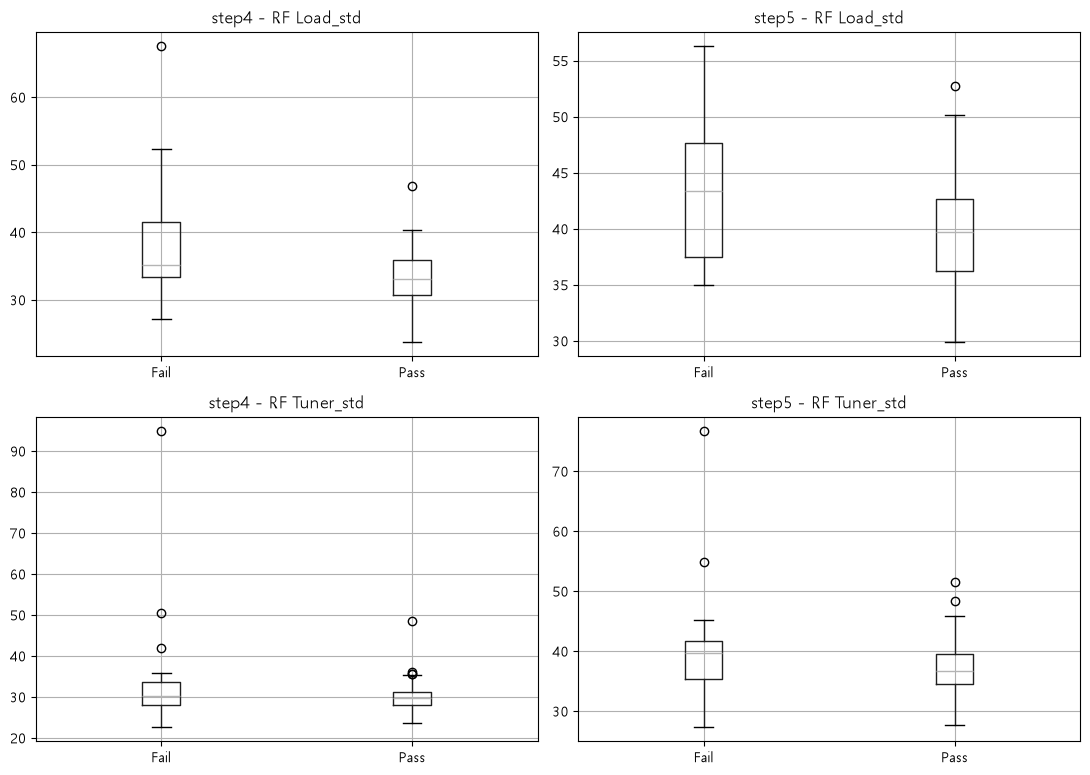

In [25]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 19-4에서 두 스텝 모두 상위권이었던 변수를 박스플롯으로 확인
top_vars = ['RF Load_std', 'RF Tuner_std']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col_idx, (agg_df, label) in enumerate([(step4_agg_df, 'step4'), (step5_agg_df, 'step5')]):
    for row_idx, var in enumerate(top_vars):
        ax = axes[row_idx, col_idx]
        agg_df.boxplot(column=var, by='result', ax=ax)
        ax.set_title(f'{label} - {var}')
        ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

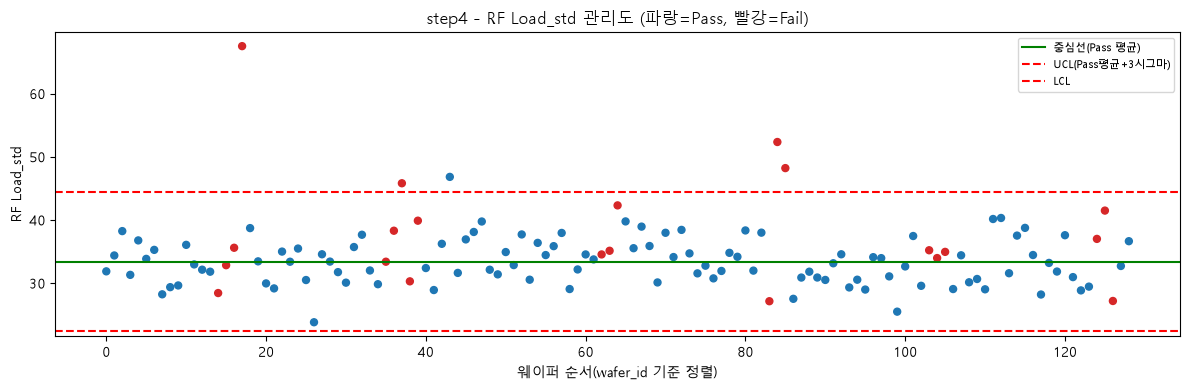

[step4] UCL/LCL을 벗어난 웨이퍼 수: 5 (그중 실제 Fail: 4/21, 잘못 걸린 Pass: 1)


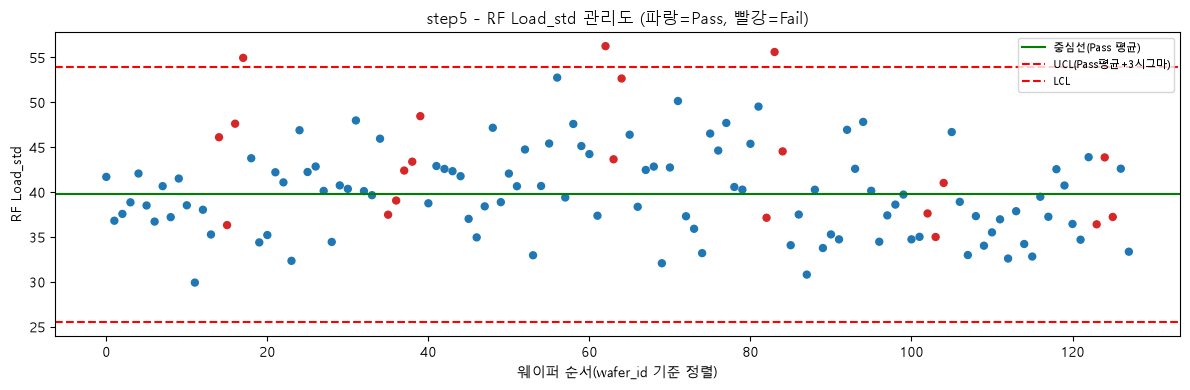

[step5] UCL/LCL을 벗어난 웨이퍼 수: 3 (그중 실제 Fail: 3/21, 잘못 걸린 Pass: 0)


In [26]:
# RF Load_std를 웨이퍼 순서로 늘어놓고 관리도(3-시그마)를 그린다
# 중심선/관리한계는 Pass 웨이퍼만으로 구한다 - '정상 상태'의 흔들림 범위를 기준으로 삼기 위해
def plot_control_chart(agg_df, var, label):
    df_sorted = agg_df.sort_values('wafer_id').reset_index(drop=True)
    pass_vals = df_sorted.loc[df_sorted['result'] == 'Pass', var]
    cl = pass_vals.mean()
    sigma = pass_vals.std()
    ucl = cl + 3 * sigma
    lcl = max(cl - 3 * sigma, 0)  # 표준편차 값이라 음수는 의미가 없어 0으로 자른다

    fig, ax = plt.subplots(figsize=(12, 4))
    colors = df_sorted['result'].map({'Pass': 'tab:blue', 'Fail': 'tab:red'})
    ax.scatter(range(len(df_sorted)), df_sorted[var], c=colors, s=25)
    ax.axhline(cl, color='green', linestyle='-', label='중심선(Pass 평균)')
    ax.axhline(ucl, color='red', linestyle='--', label='UCL(Pass평균+3시그마)')
    ax.axhline(lcl, color='red', linestyle='--', label='LCL')
    ax.set_title(f'{label} - {var} 관리도 (파랑=Pass, 빨강=Fail)')
    ax.set_xlabel('웨이퍼 순서(wafer_id 기준 정렬)')
    ax.set_ylabel(var)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

    out_of_control = df_sorted[(df_sorted[var] > ucl) | (df_sorted[var] < lcl)]
    fail_caught = int((out_of_control['result'] == 'Fail').sum())
    fail_total = int((df_sorted['result'] == 'Fail').sum())
    pass_flagged = int((out_of_control['result'] == 'Pass').sum())
    print(f'[{label}] UCL/LCL을 벗어난 웨이퍼 수: {len(out_of_control)} (그중 실제 Fail: {fail_caught}/{fail_total}, 잘못 걸린 Pass: {pass_flagged})')
    return fail_caught, fail_total, pass_flagged, len(out_of_control)

r4 = plot_control_chart(step4_agg_df, 'RF Load_std', 'step4')
r5 = plot_control_chart(step5_agg_df, 'RF Load_std', 'step5')

### 19-6) step5 4개 모델 비교표

| 지표 | 기준모델(행) | 로지스틱 회귀 일반(행) | 로지스틱회귀-클래스가중치(행) | 압축-로지스틱(일반) | 압축-로지스틱(balanced) |
|---|---|---|---|---|---|
| 시험용 단위 | 행 | 행 | 행 | 웨이퍼 | 웨이퍼 |
| 시험용 전체 개수 | 1,380 | 1,380 | 1,380 | 26 | 26 |
| 정확도 | 0.8442 | 0.8399 | 0.5464 | 0.8077 | 0.8077 |
| 지목한 건수 | - | 6 | 463 | 1 | 3 |
| 그중 진짜 | - | 0 | 26 | 0 | 1 |
| 시험용의 실제 건수 | 215 | 215 | 215 | 4 | 4 |
| 정밀도 | - | 0.0 | 0.0562 | 0.0 | **0.3333** |
| 재현율 | - | 0.0 | 0.1209 | 0.0 | **0.25** |
| F1 | - | 0.0 | 0.0767 | 0.0 | **0.2857** |

step5에서는 step4와 다르게 압축-로지스틱 **일반**이 아니라 **balanced**가 더 나은 결과를 냈다(F1 0.2857 vs 0.0). 압축-로지스틱(일반)은 시험용 웨이퍼 4개 중 1개도 못 잡았다.

---
## Step 9. 최종 정리

### 1) 데이터셋을 계속 수정한 이유

| 시점 | 만든 파일 | 수정 이유 |
|---|---|---|
| 16-3 | `lam_etch_modify_2.csv` | `TCP Rfl Pwr`에 물리적으로 불가능한 -1값이 1건 있었다 — 계측 노이즈로 판단해 0으로 교정 (원본 `lam_etch_modify.csv`는 그대로 둠) |
| 16-3 | `lam_etch_step4.csv`, `lam_etch_step5.csv` | `Step Number` 4/5는 공정 특성(BCl3 Flow, Pressure 등 기초통계)이 서로 달라서, 섞어서 학습시키면 "스텝이 달라서 나는 차이"와 "불량이라서 나는 차이"가 뒤섞인다 — 그래서 스텝별로 분리했고, 분리 후 상수가 된 `Step Number` 열은 제거, `wafer_id`는 나중에 웨이퍼 단위로 되돌리기 위해 유지 |
| Step 7 | `lam_etch_step4_agg.csv`, `lam_etch_step5_agg.csv` | 16-5에서 확인했듯 행(시점) 단위 원시값은 label(웨이퍼 단위)과 관계가 거의 없었다(실제 Fail 행의 예측 확률이 오히려 더 낮았음) — label과 입력의 단위를 맞추기 위해 웨이퍼당 여러 시점을 평균·표준편차로 압축 |

공통적으로, 매번 원본은 절대 덮어쓰지 않고 새 파일로만 저장했고 수정 전/후를 코드로 직접 대조해서 확인했다.

### 2) 시계열 전체 사용 vs 웨이퍼별 압축 사용의 차이

| | 시계열 전체(행 단위) | 웨이퍼별 압축 |
|---|---|---|
| 볼 수 있는 것 | 시점별 순간적 변화 — 언제 반사전력이 튀었는지, 어느 시점에 어떤 값이었는지 | 웨이퍼 전체의 경향(평균 수준)과 흔들림 정도(표준편차) |
| 볼 수 없는 것 | label이 웨이퍼 단위라 "이 시점이 특별히 이상했는가"를 라벨과 직접 연결하지 못함(16-5에서 확인) | 어느 시점에 무슨 일이 있었는지는 사라짐 — 평균 내는 순간 스파이크가 묻힘 |
| 표본 단위 | 웨이퍼 1개 = 행 수십~수백 개 | 웨이퍼 1개 = 행 1개 |
| 실제 결과 | 로지스틱 회귀 일반이 Fail을 거의 못 잡음(F1 0~0.05 수준) | 최소 한쪽 모델(step4는 일반, step5는 balanced)에서 F1 0.29~0.33까지 개선 |

**이용 시 주의사항**
- 행 단위를 쓸 때는 반드시 `wafer_id` 기준으로 학습/시험을 나눠야 한다 — 안 그러면 같은 웨이퍼의 다른 시점이 학습·시험에 동시에 들어가는 leakage가 생긴다
- 압축 단위를 쓸 때는 표준편차가 웨이퍼당 시점 수(최소 3개)에 따라 신뢰도가 다르다는 점, 그리고 웨이퍼 수 자체(129/128개, Fail 21개)는 압축해도 늘어나지 않는다는 점을 감안해야 한다
- 어느 쪽이든 상관관계일 뿐 인과관계가 아니라는 한계는 동일하다

### 3) 기준모델 / 로지스틱회귀-일반 / 로지스틱회귀-가중치 / 압축 모델 총비교

| 모델 | step4 F1 | step5 F1 |
|---|---|---|
| 기준모델(전부 양품) | 0(정의상 Fail을 하나도 못 잡음) | 0 |
| 로지스틱회귀-일반(행 단위) | 0.0 | 0.0 |
| 로지스틱회귀-클래스가중치(행 단위) | 0.0549 | 0.0767 |
| 압축-로지스틱(일반) | **0.3333** | 0.0 |
| 압축-로지스틱(balanced) | 0.25 | **0.2857** |

행 단위 모델은 두 스텝 모두 F1이 0.08 이하로 사실상 못 쓰는 수준이었다. 압축 모델로 바꾸고 나서야 F1이 0.25~0.33대로 올라왔는데, **어떤 버전(일반 vs balanced)이 더 나은지는 스텝마다 달랐다** — step4는 일반이, step5는 balanced가 더 나았다. 시험용 Fail이 스텝당 4개뿐이라 이 순위 자체가 우연에 크게 좌우될 수 있다는 점은 감안해야 한다(2번 문항의 주의사항과 동일).

### 4) step4 vs step5, 불량이 더 뚜렷한 단계와 변수

**Fail 웨이퍼 개수 자체는 두 스텝이 동일하다(21개)** — `result`는 웨이퍼 단위 라벨이라 같은 웨이퍼는 step4든 step5든 같은 결과를 갖기 때문이다(step5에만 없는 웨이퍼 `l3125.txm` 1개는 Pass였다). 그래서 "어느 단계에서 불량이 더 많이 발생했나"는 건수로는 답할 수 없고, 대신 19-4에서 각 스텝의 Pass/Fail 그룹 간 센서 평균 차이를 표준편차로 나눈 값(효과크기)으로 "불량의 흔적이 얼마나 뚜렷한가"를 비교했다.

- **step4**가 **step5**보다 Pass/Fail 격차가 전반적으로 더 크다 (상위 5개 변수의 |효과크기|가 0.67~0.90 vs 0.52~0.74) — 압축 모델의 F1도 step4(0.3333)가 step5(0.2857)보다 높게 나온 것과 방향이 일치한다. 즉 **불량의 흔적은 step5보다 step4에서 더 뚜렷하게 남는다.**
- 두 스텝 모두에서 공통으로 상위권에 오른 변수는 **`RF Load`의 표준편차**(step4 1위, step5 1위)와 **`RF Tuner`의 표준편차**(step4 5위, step5 2위)다. 둘 다 RF 매칭 네트워크(임피던스 정합)의 튜너 위치값으로, **평균값 자체보다 그 웨이퍼 안에서 값이 얼마나 흔들렸는지가 불량과 더 관련이 크다.** `Pressure`의 표준편차, `BCl3 Flow`의 평균도 두 스텝 모두 상위 5위 안에 들었다.
- 주의: 이건 상관관계이지 인과관계가 아니다(3번 문항과 동일한 한계). 어느 변수가 원인인지는 이 분석만으로 확정할 수 없고, RF 매칭 네트워크 쪽을 더 들여다볼 필요가 있다는 힌트 정도로 봐야 한다.

---
## Step 10. 목적에 맞는 모델 추천

**목적**: Etch 공정에서 불량 공정 파라미터를 조기 탐지해 수율 저하를 방지한다.

### 지금까지 실제로 확인한 탐지 성능

| 방법 | 평가 방식 | 잡아낸 Fail | 오탐(Pass를 잘못 지목) |
|---|---|---|---|
| 로지스틱회귀(행 단위, 일반/가중치) | 시험용 26웨이퍼(1,234~1,380행) | 0~26/192~215건 (F1 0~0.08) | 매우 많음(최대 463건) 또는 0건 |
| 압축-로지스틱(웨이퍼 단위) | 시험용 웨이퍼 4개 (전체 129개 중 20%) | step4: 1/4(F1 0.33) · step5: 1/4(F1 0.29) | 1~3건 |
| **RF Load_std 관리도(3-시그마)** | 전체 웨이퍼(129개/128개) | **step4: 4/21(19%) · step5: 3/21(14%)** | **step4: 1건 · step5: 0건** |

(관리도는 학습/시험을 나누지 않고 전체 웨이퍼에 적용한 결과라 위 로지스틱 모델들과 평가 방식이 다르다는 점은 감안해야 한다. 그래도 오탐이 1건 이하로 압도적으로 적다는 것 자체가 의미 있는 차이다.)

### 최종 추천: RF Load_std 관리도를 1차 조기경보로, 압축-로지스틱회귀를 보조로 병행

**1순위 — RF Load_std 3-시그마 관리도**
- 이유: 19-4/19-5에서 `RF Load`의 표준편차(그 웨이퍼 안에서 RF 매칭 튜너가 얼마나 흔들렸는지)가 step4·step5 모두에서 Pass/Fail을 가장 뚜렷하게 가르는 변수였다. 이 변수 하나만으로 그린 관리도가 오탐 1건 이하로 불량의 14~19%를 잡아내, 지금까지 만든 어떤 모델보다도 정밀도가 높다.
- 실무 적합성: 학습·재학습이 필요 없고, 웨이퍼 공정이 끝나는 즉시 그 자리에서 판정할 수 있다. 엔지니어가 "왜 걸렸는지"(RF Load 튜너가 평소보다 얼마나 벗어났는지)를 바로 알 수 있어 "조기 탐지 → 원인 파악 → 조치"로 이어지는 실제 목적에 가장 직접적으로 맞는다.
- 한계: 변수 하나만 보므로 여러 센서가 동시에 조금씩 이상한 다변량 패턴은 놓칠 수 있고, 잡아내는 비율(14~19%) 자체가 아직 낮다.

**2순위 — 압축-로지스틱회귀 (class_weight는 상황에 맞게 검증)**
- 이유: 19개 센서를 동시에 보기 때문에, 관리도 하나로는 못 잡는 다변량 이상을 보완할 수 있다. 정밀도 33~50%로 관리도보다는 낮지만, 로지스틱 회귀라 계수를 보면 어떤 센서가 원인인지 계속 추적할 수 있다.
- 한계: step4는 일반 로지스틱이, step5는 class_weight='balanced'가 더 나아서 최적 설정이 스텝마다 달랐다 — 실제 배포 전에는 매 레시피/스텝마다 어떤 설정이 나은지 별도로 검증해야 한다. 또한 웨이퍼 129개(Fail 21개)라는 표본 자체가 작아 재현성 확인이 계속 필요하다.

**공통 한계**: 두 방법 모두 Fail의 대부분(80% 이상)은 여전히 놓친다. 이건 어떤 모델을 쓰든 지금 가진 Fail 표본(21개)이 근본적으로 작기 때문이라, 더 많은 불량 데이터가 쌓일수록 개선 여지가 크다.

---
## Step 11. Etch 공정 이상탐지 최종 전략

### 전체 그림 - 3단계

| 단계 | 무엇을 보나 | 방법 | 목적 |
|---|---|---|---|
| ① 실시간층 (raw, within-run) | 공정 진행 중 매 시점 원시값 | 임계값/급변 감시 (이번 분석 범위 밖) | 순간적 이상을 즉시 중단시키는 용도 - 16-5에서 시점 단위 원시값은 label과 신호가 약하다는 걸 확인했지만, "이 순간이 비정상인가"는 여전히 별도로 볼 가치가 있다 |
| ② 런투런층 (웨이퍼 단위 요약값) | 웨이퍼 하나가 끝난 뒤의 요약 통계(평균·표준편차) | **RF Load_std 관리도(Xbar-S 개념) + 압축-로지스틱회귀(38피처)** — 병행, 서로 배타적으로 나누지 않음 | 이번 분석의 핵심. 웨이퍼 완료 즉시 "이 웨이퍼를 다음 공정으로 보내도 되는가"를 판정 |
| ③ 드릴다운층 (원인 분석) | ②에서 Fail로 지목된 웨이퍼의 원본 시계열 | 그 웨이퍼의 `lam_etch_step4.csv`/`step5.csv` 원본 행을 다시 불러와, 로지스틱회귀 계수가 컸던 변수 위주로 시점별 추이 확인 | 압축 과정에서 잃어버린 "언제, 어떻게 이상이 있었는지"를 필요한 웨이퍼에 한해 복원 - 실제 원인 파악 및 조치로 연결 |

### ②번이 정석에 맞는 이유

한 웨이퍼는 RF Load 등 센서를 47~53번 반복 측정한 "서브그룹(subgroup)"으로 볼 수 있다. SPC의 표준 기법인 Xbar-S 관리도가 서브그룹의 평균은 Xbar 차트, 서브그룹 안에서의 흔들림은 S차트(표준편차)로 나눠 보는 것과 정확히 같은 구조다. `RF Load_std` 관리도는 이 S차트에 해당하고, 반도체 팹의 실제 FDC 시스템도 원시 트레이스 그대로가 아니라 트레이스별 평균·표준편차 같은 요약값(trace statistics)에 SPC를 적용하는 방식을 표준적으로 쓴다.

### ②번 두 방법을 병행하는 이유 (역할을 나누지 않는 이유)

`RF Load_std`를 관리도에서 뺀 뒤 압축-로지스틱회귀에만 넣는 식으로 역할을 딱 나누지 않는다 — 둘 다 전체 38피처를 보게 둔다.
- 두 방법이 같은 웨이퍼를 동시에 지목하면 → 신뢰도가 높다는 신호
- 서로 다른 웨이퍼를 지목하면 → 관리도(단변량)와 로지스틱회귀(다변량)가 서로 다른 종류의 이상을 보완하고 있다는 신호

### 실제 근거 데이터 (지금까지 실행한 결과)

| 방법 | 평가 방식 | 잡아낸 Fail | 오탐 |
|---|---|---|---|
| 로지스틱회귀(행 단위) | 시험용 26웨이퍼 | 0~26/192~215건 (F1 0~0.08) | 매우 많거나 0건 |
| 압축-로지스틱(웨이퍼 단위) | 시험용 웨이퍼 4개 | step4 1/4(F1 0.33) · step5 1/4(F1 0.29) | 1~3건 |
| **RF Load_std 관리도** | 전체 웨이퍼 129/128개 | **step4 4/21(19%) · step5 3/21(14%)** | **step4 1건 · step5 0건** |
| 19-4 효과크기 분석 | 전체 웨이퍼 | `RF Load_std`, `RF Tuner_std`가 두 스텝 모두 Pass/Fail 격차 상위 | - |

### 한계 - 어떤 조합을 쓰든 남는 문제

- Fail 웨이퍼가 21개뿐이라, 위 세 방법 모두 전체 Fail의 80% 이상은 여전히 놓친다. 이건 모델·기법의 문제가 아니라 표본 자체의 한계라 더 많은 불량 데이터가 쌓여야 개선된다.
- 관리도·로지스틱회귀 모두 상관관계 기반이다 — `RF Load_std`가 높다고 그것이 불량의 "원인"이라고 단정할 수 없고, ③ 드릴다운으로 원본 시계열을 봐도 여전히 "정황 증거"이지 인과관계 증명은 아니다.
- 압축-로지스틱회귀는 step4·step5에서 최적 class_weight 설정이 달랐다 - 실제 배포 전 레시피/스텝마다 재검증이 필요하다.